# DocVQA 2026 Dataset Exploration

Explore the [ICDAR 2026 DocVQA](https://rrc.cvc.uab.es/?ch=34) dataset: size, category distribution, page counts, question types, and visual examples.

In [2]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt

ds = load_dataset("VLR-CVC/DocVQA-2026", split="val")
print(f"Validation set: {len(ds)} documents")
print(f"Columns: {ds.column_names}")

Validation set: 25 documents
Columns: ['doc_id', 'doc_category', 'preview', 'document', 'questions', 'answers']


## Build a summary DataFrame

In [3]:
rows = []
for sample in ds:
    n_questions = len(sample["questions"]["question_id"])
    n_pages = len(sample["document"])
    rows.append({
        "doc_id": sample["doc_id"],
        "category": sample["doc_category"],
        "num_pages": n_pages,
        "num_questions": n_questions,
    })

df = pd.DataFrame(rows)
df.head(10)

,doc_id,category,num_pages,num_questions
0,comics_1,comics,36,1
1,comics_2,comics,52,4
2,comics_3,comics,60,3
3,comics_4,comics,69,2
4,maps_1,maps,1,2
5,maps_2,maps,1,5
6,maps_3,maps,1,3
7,engineering_drawing_1,engineering_drawing,7,3
8,engineering_drawing_2,engineering_drawing,1,2
9,engineering_drawing_3,engineering_drawing,6,3


## Category distribution

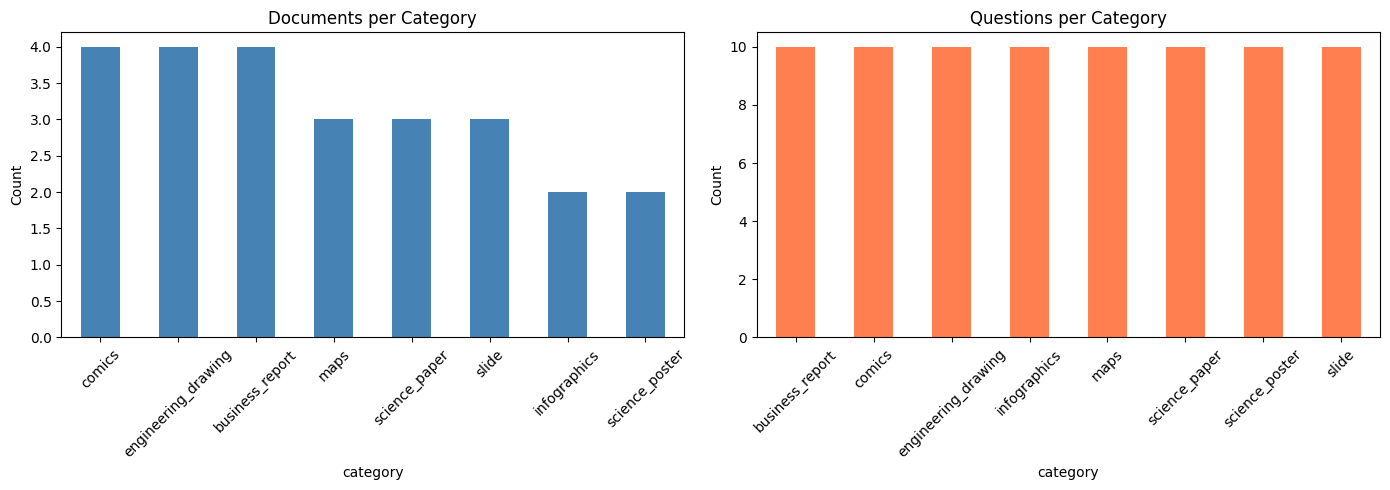


Total documents: 25
Total questions: 80

Documents per category:
category
comics                 4
engineering_drawing    4
business_report        4
maps                   3
science_paper          3
slide                  3
infographics           2
science_poster         2

Questions per category:
category
business_report        10
comics                 10
engineering_drawing    10
infographics           10
maps                   10
science_paper          10
science_poster         10
slide                  10


In [4]:
cat_counts = df["category"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Documents per category
cat_counts.plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title("Documents per Category")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Questions per category
q_per_cat = df.groupby("category")["num_questions"].sum()
q_per_cat.plot.bar(ax=axes[1], color="coral")
axes[1].set_title("Questions per Category")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"\nTotal documents: {len(df)}")
print(f"Total questions: {df['num_questions'].sum()}")
print(f"\nDocuments per category:\n{cat_counts.to_string()}")
print(f"\nQuestions per category:\n{q_per_cat.to_string()}")

## Page count distribution

In [5]:
page_stats = df.groupby("category")["num_pages"].agg(["min", "max", "mean", "median"])
page_stats = page_stats.round(1)
print("Page count statistics per category:")
page_stats

Page count statistics per category:


,min,max,mean,median
category,,,,
business_report,89,181,121.2,107.5
comics,36,69,54.2,56.0
engineering_drawing,1,7,4.2,4.5
infographics,1,1,1.0,1.0
maps,1,1,1.0,1.0
science_paper,19,44,31.0,30.0
science_poster,1,1,1.0,1.0
slide,18,36,28.7,32.0


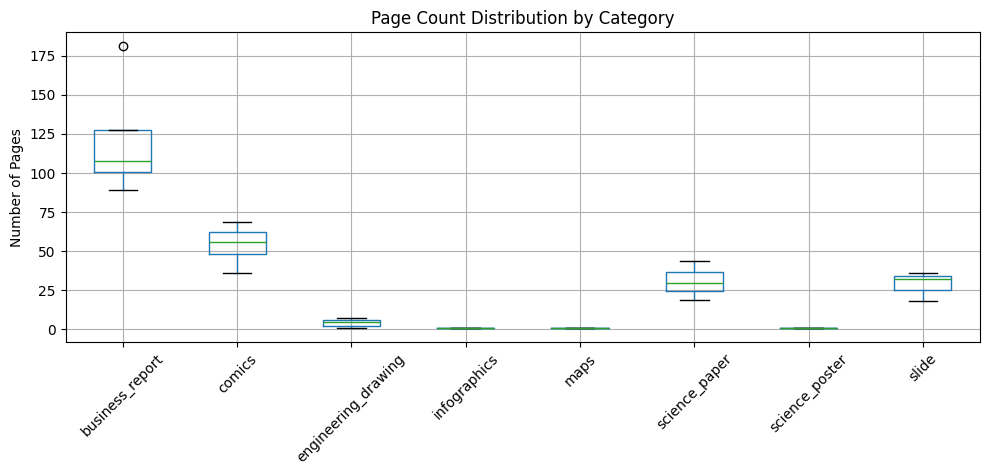

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
df.boxplot(column="num_pages", by="category", ax=ax, vert=True)
ax.set_title("Page Count Distribution by Category")
ax.set_ylabel("Number of Pages")
ax.set_xlabel("")
plt.suptitle("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Questions per document

In [7]:
q_stats = df.groupby("category")["num_questions"].agg(["min", "max", "mean", "median"])
q_stats = q_stats.round(1)
print("Questions per document by category:")
q_stats

Questions per document by category:


,min,max,mean,median
category,,,,
business_report,1,5,2.5,2.0
comics,1,4,2.5,2.5
engineering_drawing,2,3,2.5,2.5
infographics,2,8,5.0,5.0
maps,2,5,3.3,3.0
science_paper,1,7,3.3,2.0
science_poster,5,5,5.0,5.0
slide,2,5,3.3,3.0


## Sample questions by category

In [8]:
seen_categories = set()
for sample in ds:
    cat = sample["doc_category"]
    if cat in seen_categories:
        continue
    seen_categories.add(cat)
    qs = sample["questions"]["question"]
    ans = sample.get("answers", {}).get("answer", [])
    print(f"--- {cat} ({sample['doc_id']}) ---")
    for i, q in enumerate(qs[:3]):
        a = ans[i] if i < len(ans) else "N/A"
        print(f"  Q: {q}")
        print(f"  A: {a}")
    print()

--- comics (comics_1) ---
  Q: How many times do people get in the head in Nyoka and the Witch Doctor's Madness?
  A: 4

--- maps (maps_1) ---
  Q: If I'm standing at the Pantheon and looking toward the Colosseum, which hill will I see most clearly to the right of it?
  A: Capitolinus
  Q: I'm at the Panteon, then I walk in the direction of the Capitolinvs, before reaching it I turn left, and after a bit more I turn left again, now I follow the road until I exit the city. Through which gate have I exited?
  A: P.Popoli

--- engineering_drawing (engineering_drawing_1) ---
  Q: In which direction can you see the eight temperature sensing manifold?
  A: D
  Q: How many clamps are used in total?
  A: 27
  Q: Which labeled parts are used at the end of the tube with identifying number 1901105? List the part identification numbers, separated by commas, in the order they are placed after the tube.
  A: 1901069-002, 1901094, AN 910-2, 1016315-001

--- science_paper (science_paper_1) ---
  Q: Ho

## Visual examples — first page of one document per category

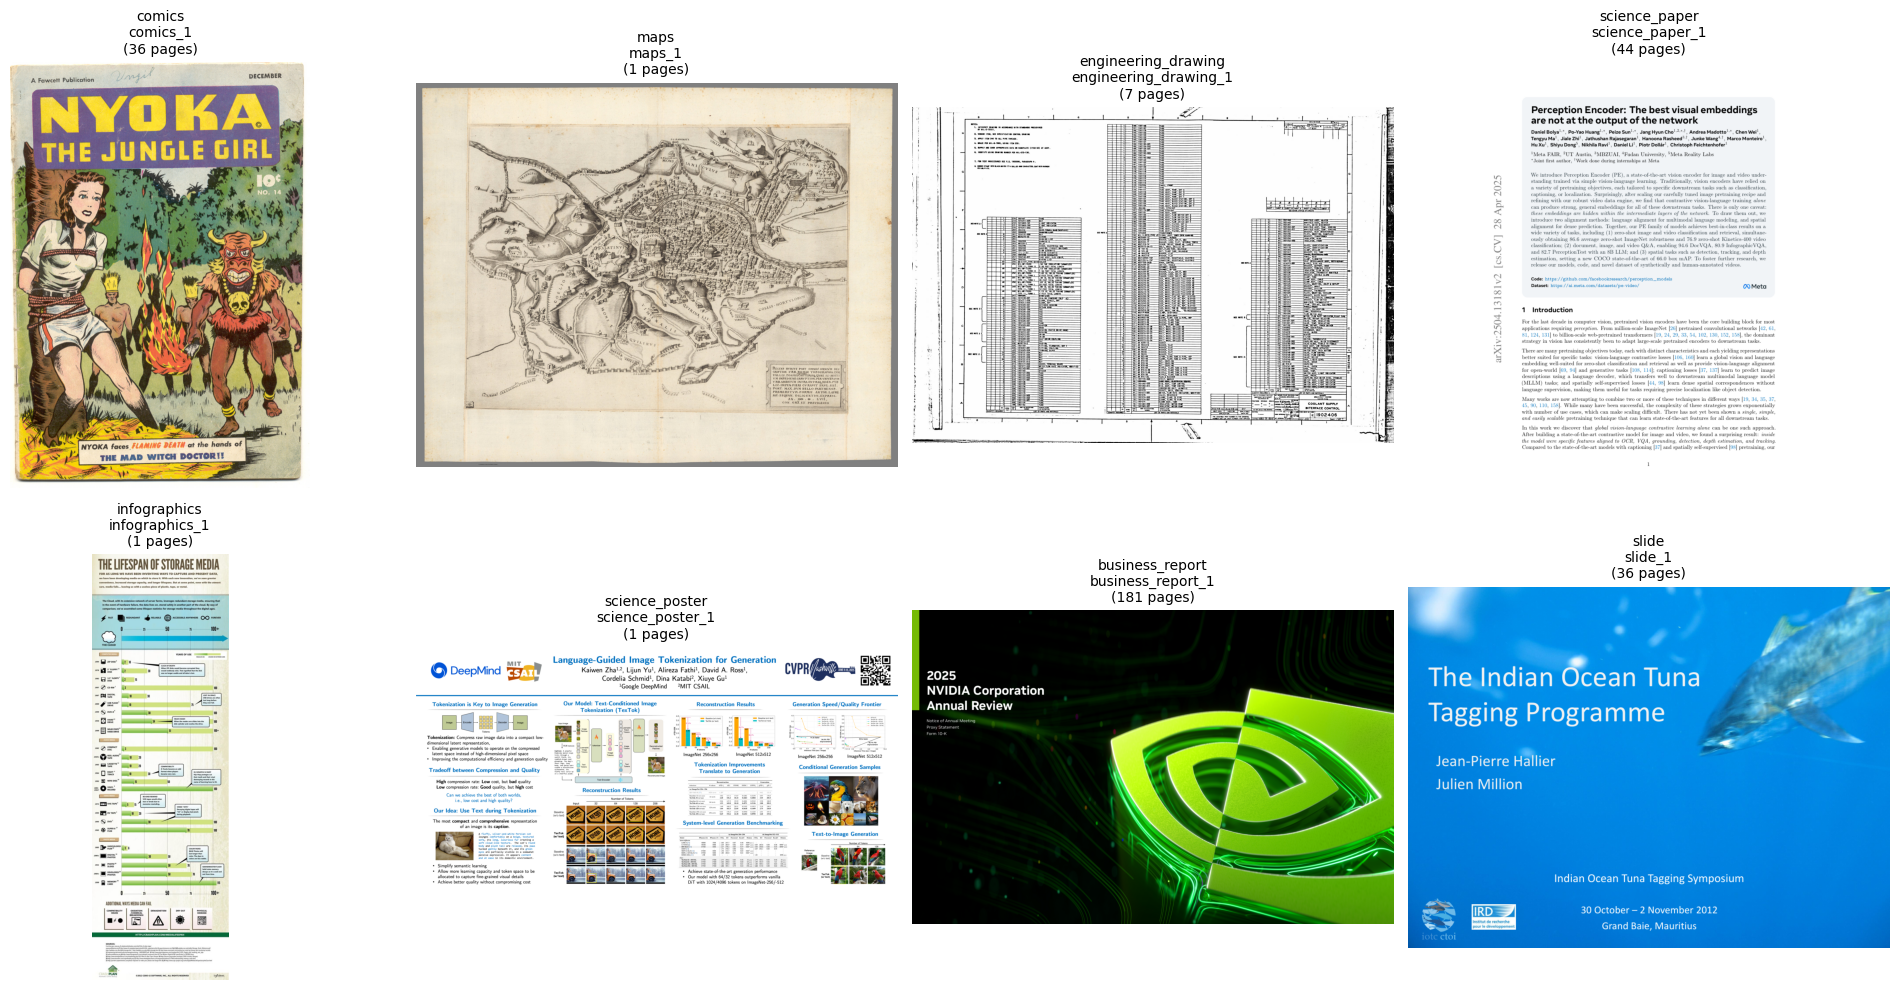

In [9]:
seen_categories = set()
examples = []
for sample in ds:
    cat = sample["doc_category"]
    if cat in seen_categories:
        continue
    seen_categories.add(cat)
    examples.append(sample)

n = len(examples)
cols = 4
rows_needed = (n + cols - 1) // cols
fig, axes = plt.subplots(rows_needed, cols, figsize=(20, 5 * rows_needed))
axes = axes.flatten()

for i, sample in enumerate(examples):
    img = sample["document"][0]  # first page
    axes[i].imshow(img)
    axes[i].set_title(f"{sample['doc_category']}\n{sample['doc_id']}\n({len(sample['document'])} pages)", fontsize=10)
    axes[i].axis("off")

for i in range(n, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Image resolution statistics

In [10]:
res_rows = []
for sample in ds:
    for page_idx, img in enumerate(sample["document"]):
        w, h = img.size
        res_rows.append({
            "doc_id": sample["doc_id"],
            "category": sample["doc_category"],
            "page": page_idx,
            "width": w,
            "height": h,
            "megapixels": round(w * h / 1e6, 2),
        })

res_df = pd.DataFrame(res_rows)
print(f"Total pages across all documents: {len(res_df)}")
print(f"\nResolution stats:")
res_df[["width", "height", "megapixels"]].describe().round(1)

Total pages across all documents: 905

Resolution stats:


,width,height,megapixels
count,905.0,905.0,905.0
mean,1089.3,1203.5,1.4
std,466.6,386.8,1.3
min,500.0,750.0,0.7
25%,850.0,1075.0,0.9
50%,892.0,1100.0,1.0
75%,1334.0,1170.0,1.2
max,4346.0,3205.0,13.9


## Summary table

In [11]:
summary = df.groupby("category").agg(
    docs=("doc_id", "count"),
    total_questions=("num_questions", "sum"),
    avg_questions=("num_questions", "mean"),
    min_pages=("num_pages", "min"),
    max_pages=("num_pages", "max"),
    avg_pages=("num_pages", "mean"),
).round(1)

summary["total_pages"] = res_df.groupby("category").size()
summary = summary[["docs", "total_pages", "min_pages", "max_pages", "avg_pages", "total_questions", "avg_questions"]]
summary.loc["TOTAL"] = [
    len(df), len(res_df), df["num_pages"].min(), df["num_pages"].max(),
    round(df["num_pages"].mean(), 1), df["num_questions"].sum(), round(df["num_questions"].mean(), 1),
]
summary = summary.astype({"docs": int, "total_pages": int, "min_pages": int, "max_pages": int, "total_questions": int})
summary

,docs,total_pages,min_pages,max_pages,avg_pages,total_questions,avg_questions
category,,,,,,,
business_report,4,485,89,181,121.2,10,2.5
comics,4,217,36,69,54.2,10,2.5
engineering_drawing,4,17,1,7,4.2,10,2.5
infographics,2,2,1,1,1.0,10,5.0
maps,3,3,1,1,1.0,10,3.3
science_paper,3,93,19,44,31.0,10,3.3
science_poster,2,2,1,1,1.0,10,5.0
slide,3,86,18,36,28.7,10,3.3
TOTAL,25,905,1,181,36.2,80,3.2
